# Data Preprocessing
In this file, we will preprocess and prepare the 'Titanic' dataset for use with the rest of the classification data.

Then, we will split this data into training and testing data.

Finally, we will perform dimensionality reduction with PCA and split that data into training and testing data.

### Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from mlxtend.plotting import plot_decision_regions

import struct

sns.set_theme()

### Data Explanation
This dataset consists of passenger data of the individuals aboard the Titanic during the accident. The goal is to predict, based on the following features, if the individual survived the accident:

- Survived (target): Whether or not the individual survived. 0 if they did not survive, 1 if they did.
- Pclass (feature): Which class the individual stayed in. 1 for first class, 2 for second class, 3 for third class.
- Age (feature): Age of individual in years
- SibSp (feature): The total number of siblings and spouses of the individual aboard.
- Parch (feature): The total number of parents and children of the individual aboard.
- Fare (feature): The fare that the individual paid.
- Sex (feature): The sex of the individual. 0 if male, 1 if female.
- Embarked_S (feature): Whether the individual embarked from Southampton. 1 if they did, 0 if they did not.
- Embarked_Q (feature): Whether the individual embarked from Queenstown. 1 if they did, 0 if they did not.
- Embarked_C (feature): Whether the individual embarked from Cherbourg. 1 if they did, 0 if they did not.
- is_man (feature): Whether the individual is a man. 1 if they are, 0 if they are not.
- is_woman (feature): Whether the individual is a woman. 1 if they are, 0 if they are not.
- is_child (feature): Whether the individual is a child. 1 if they are, 0 if they are not.
- adult_male (feature): Whether the individual is an adult male. 1 if they are, 0 if they are not.
- Alone (feature): Whether the individual was aboard alone. 1 if they were, 0 if they were not.

### Data Preprocessing
First, load in dataset, and drop redundant / mostly missing columns:

In [13]:
df = sns.load_dataset('titanic').drop(columns=["deck", "class", "embark_town", "alive"])

Replace age strings with representative numbers:

In [14]:
df['sex'] = df['sex'].replace({'male': 0, "female": 1})

/tmp/ipykernel_53387/2041917767.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'male': 0, "female": 1})


Notice how the age column has many missing numbers:

In [15]:
for col in df.columns:
    print(f"{col}: {df[col].isna().sum()}")

survived: 0
pclass: 0
sex: 0
age: 177
sibsp: 0
parch: 0
fare: 0
embarked: 2
who: 0
adult_male: 0
alone: 0


So we fill out the NaN values of the age column with the median of the age as an estimate:

In [16]:
df['age'] = df['age'].fillna(df['age'].median())

Now drop the two rows with NaNs in the "embarked" column:

In [17]:
df = df.dropna(how = "any")

Now, no more NaN values!

In [18]:
for col in df.columns:
    print(f"{col}: {df[col].isna().sum()}")

survived: 0
pclass: 0
sex: 0
age: 0
sibsp: 0
parch: 0
fare: 0
embarked: 0
who: 0
adult_male: 0
alone: 0


Now, we look at the remaining categorical data. We will not one hot encode parch or sibsp, as they have an innate ordering to them. However, embarked and who do not have any innate ordering, so we will one hot encode them:

In [19]:
# now one hot encode a few cols
df['embarked_S'] = (df['embarked'] == "S").astype(np.int64)
df['embarked_C'] = (df['embarked'] == "C").astype(np.int64)
df['embarked_Q'] = (df['embarked'] == "Q").astype(np.int64)
df['is_man'] = (df['who'] == 'man').astype(np.int64)
df['is_woman'] = (df['who'] == 'woman').astype(np.int64)
df['is_child'] = (df['who'] == 'child').astype(np.int64)
df = df.drop(columns=['embarked', 'who'])

Now, convert the remaining True / False values to integer values.

In [20]:
df['adult_male'] = df['adult_male'].astype(np.int64)
df['alone'] = df['alone'].astype(np.int64)

Now, display the data:

In [21]:
df

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_S,embarked_C,embarked_Q,is_man,is_woman,is_child
0,0,3,0,22.0,1,0,7.2500,1,0,1,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,0,0,0,1,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,0,0,0,1,0
3,1,1,1,35.0,1,0,53.1000,0,0,1,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,1,1,1,0,0,1,0,0
887,1,1,1,19.0,0,0,30.0000,0,1,1,0,0,0,1,0
888,0,3,1,28.0,1,2,23.4500,0,0,1,0,0,0,1,0
889,1,1,0,26.0,0,0,30.0000,1,1,0,1,0,1,0,0


### Train / Test Split

First, set train/test split parameters:

In [22]:
train_test_ratio = 0.7
train_cutoff = round(train_test_ratio * df.shape[0])

Now, perform the split:

In [28]:
X_data = df.iloc[:, 1:].to_numpy()
y_data = df.iloc[:, 0].to_numpy()
train_X = df.iloc[:train_cutoff, 1:].to_numpy()
test_X = df.iloc[train_cutoff:, 1:].to_numpy()
train_y = df.iloc[:train_cutoff, 0].to_numpy()
test_y = df.iloc[train_cutoff:, 0].to_numpy()

### PCA

The Principal Component Analysis (PCA) algorithm aims to reduce the dimension of a given dataset while retaining the maximum amount of variance. It essentially identifies the most important principal components of the dataset, and reduces the dataset down to those principal components.

Suppose $X$ is the original dataset and $k$ is the number of principal components that we want to retain.

First, we must standardize the data so that each feature has a mean of zero and a standard deviation of 1 by setting it as such: $$\hat{X} = \frac{X - \mu}{\sigma}$$

Then, we compute the SVD for our new transformed dataset: $$\hat{X} = U\Sigma V^{T}$$

Finally, we multiply the transformed dataset by the first $k$ columns of $V$: $$\hat{X}^* = \hat{X} V_k$$

Then $\hat{V}^*$ contains the first $k$ principal components of the dataset.


Standardizing the data:

In [32]:
PCA_X_data = np.empty(np.shape(X_data))
PCA_y_data = y_data[:]
for i in range(np.shape(X_data)[1]):
    mean = np.mean(X_data[:, i])
    std = np.std(X_data[:, i])
    PCA_X_data[:, i] = (X_data[:, i] - mean) / std
PCA_X_data

array([[ 0.82520863, -0.73534203, -0.56367407, ...,  0.80962552,
        -0.65868882, -0.32090134],
       [-1.57221121,  1.35991138,  0.66921696, ..., -1.23513893,
         1.51816755, -0.32090134],
       [ 0.82520863,  1.35991138, -0.25545131, ..., -1.23513893,
         1.51816755, -0.32090134],
       ...,
       [ 0.82520863,  1.35991138, -0.10133993, ..., -1.23513893,
         1.51816755, -0.32090134],
       [-1.57221121, -0.73534203, -0.25545131, ...,  0.80962552,
        -0.65868882, -0.32090134],
       [ 0.82520863, -0.73534203,  0.20688282, ...,  0.80962552,
        -0.65868882, -0.32090134]], shape=(889, 14))

Perform SVD

In [35]:
U, S, V = np.linalg.svd(PCA_X_data)

Now, we must decide how many components to retain. We will do this by comparing relative variances through a scree plot.

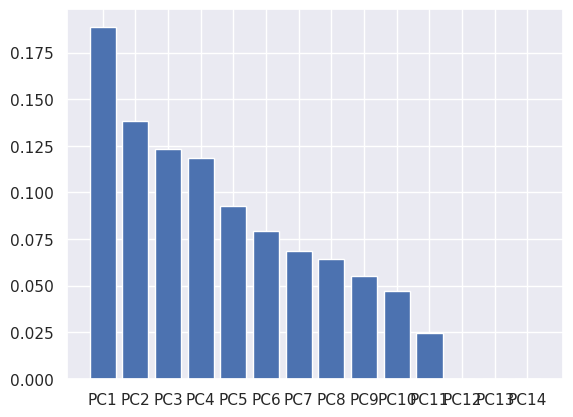

In [36]:
SVD_sum = sum(S)
labels = [f"PC{i}" for i in range(1, len(S)+1)]
relative_variances = S / SVD_sum
plt.bar(labels, relative_variances)
plt.show()

For data visualization purposes, we will use the first two components. However, in reality, we should be using the first 11 components.

Set PCA dimension

In [37]:
k = 2

In [38]:
A_new = PCA_X_data @ V[:, :k]
A_new

array([[ 0.27091125,  0.68098554],
       [ 0.53277476, -0.55371728],
       [ 0.0345545 ,  0.39015073],
       ...,
       [ 1.24016086,  0.21642602],
       [-1.19541552, -0.32452967],
       [ 0.32696453, -2.13358485]], shape=(889, 2))

### PCA Train/Test Split

In [40]:
PCA_train_X = A_new[:train_cutoff, :]
PCA_test_X = A_new[train_cutoff:, :]
PCA_train_y = PCA_y_data[:train_cutoff]
PCA_test_y = PCA_y_data[train_cutoff:]
PCA_train_X

array([[ 0.27091125,  0.68098554],
       [ 0.53277476, -0.55371728],
       [ 0.0345545 ,  0.39015073],
       ...,
       [-0.18216716,  0.69299342],
       [ 0.63367426, -0.01128068],
       [-0.26705797,  0.47826367]], shape=(622, 2))

### Save to files

In [42]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/Titanic-Dataset"
np.save(f"{data_dir}/train_X.npy", train_X)
np.save(f"{data_dir}/train_y.npy", train_y)
np.save(f"{data_dir}/test_X.npy", test_X)
np.save(f"{data_dir}/test_y.npy", test_y)
np.save(f"{data_dir}/PCA_train_X.npy", PCA_train_X)
np.save(f"{data_dir}/PCA_train_y.npy", PCA_train_y)
np.save(f"{data_dir}/PCA_test_X.npy", PCA_test_X)
np.save(f"{data_dir}/PCA_test_y.npy", PCA_test_y)